# Aprendizaje de Máquina

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Chunga, Juan Miguel (juanmiguel.ch2014@gmail.com)
- Gonzalez, Juan (juan.gonzalez.working@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Carga del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [3]:
body_fat_dataset = pd.read_csv("./dataset/bodyfat.csv")

In [99]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Descripción general del dataset

Para este trabajo final se seleccionó el [Body Fat Prediction](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset) dataset de la plataforma [Kaggle](https://www.kaggle.com/).

Este dataset se caracteriza por tener información correspondiente a las mediciones del porcentaje de grasa corporal de distintas personas, presentada en 252 registros con 15 columnas.

Las columnas son las siguientes:

| Columna | Descripción |
| --- | --- |
| Density | Densidad, determinada a partir del pesaje debajo del agua |
| BodyFat | Porcentaje de grasa corporal, acorde a la [ecuación de Siri](https://www.sciencedirect.com/science/article/pii/S1279770723024442) |
| Age | Edad, medida en años |
| Weight | Peso, en libras |
| Height | Altura, en pulgadas |
| Neck | Circunferencia del cuello, medida en centímetros |
| Chest | Circunferencia del pecho, en centímetros |
| Abdomen | Circunferencia del abdomen, en centímetros |
| Hip | Circunferencia de la cintura, en centímetros |
| Thigh | Circunferencia del muslo, en centímetros |
| Knee | Circunferencia de la rodilla, en centímetros |
| Ankle | Circunferencia del tobillo, en centímetros |
| Bicep | Circunferencia del bicep (extendido), en centímetros |
| Forearm | Circunferencia del antebrazo, en centímetros |
| Wrist | Circunferencia de la muñeca, en centímetros |

## Descripción del problema a resolver

***TO-DO***: describir el problema

## Paso 1 - Análisis exploratorio del dataset

### Paso 1.1 - Análisis de columnas del dataset

Comenzamos analizando la dimensión del dataset, la cual se observa que es de $252$ filas por $15$ columnas.

In [6]:
body_fat_dataset.shape

(252, 15)

En la siguiente celda se muestran las primeras 5 filas del dataset, para tener una primera visión de las mismas.

In [5]:
body_fat_dataset.head(5)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


Mostramos mediante el método `describe` algunas características de cada columna, tales como la cantidad total (*count*), media (*mean*), desvío estandar (*std*), valores mínimos y máximos (*min* y *max*), y los percentiles *25%*, *50%* y *75%*.

In [4]:
body_fat_dataset.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


A continuación se definen una serie de funciones que nos permitirán analizar ciertas métricas de cada columna:

In [60]:
# Devuelve métricas relacionadas al rango Intercuartil
def metricas_iqr(data):
    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [ ]:
# Devuelve varias métricas de una columna
def obtener_metricas_columna(dataset, col):
    data = dataset[col]

    skewness = data.skew()
    kurtosis = data.kurt()
    media = data.mean()
    moda = data.mode()[0]
    mediana = data.median()
    var = data.std()
    min = data.min()
    max = data.max()
    nunique = data.nunique()
    mask_cant_ceros = data == 0
    cant_ceros = len(dataset[mask_cant_ceros])

    Q1, _, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    return media, moda, mediana, var, min, max, nunique, cant_ceros, Q1, Q3, IQR, min_iqr, max_iqr, skewness, kurtosis

In [92]:
def mostrar_metricas_dataset(dataset):
    print(f"\tColumna\t|\tMedia\t\t\t|\tModa\t|\tMediana\t|\tVarianza\t\t|\tMínimo\t|\tMáximo\t|\tCant. Únicos\t|\tCant. ceros\t|\tSkewness\t\t|\tKurtosis\t\t|")
    for col in dataset.columns:
        media, moda, mediana, var, min, max, nunique, cant_ceros, _, _, _, _, _, skewness, kurtosis = obtener_metricas_columna(dataset=dataset, col=col)

        print(f"\t{col}\t|\t{media}\t|\t{moda}\t|\t{mediana}\t|\t{var}\t|\t{min}\t|\t{max}\t|\t{nunique}\t\t|\t{cant_ceros}\t\t|\t{skewness}\t|\t{kurtosis}\t|")

En la siguiente tabla se pueden observar otras métricas que se calcularon sobre cada columna, tales como:

- Cant. únicos: muestra la cantidad de valores únicos en cada columna. Se recuerda que hay 252 registros totales.
- Cant. ceros: muestra la cantidad de registros con valor cero en cada columna. En todo el dataset hay un solo cero, y corresponde a un registro con `BodyFat` cero.
- `Skewness`: indica si la distribución de una variable presenta asimetría o no.
    - Un valor positivo indica asimetría a derecha.
    - Un valor negativo indica asimetría a izquierda.
    - Se calcula con la función [Skew](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html) de pandas.
- `Kurtosis`: describe la forma de una distribución de una variable, en particular, su cola o su pico en relación con una distribución Normal.
    - Se calcula con la función [kurt](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.kurt.html#pandas-dataframe-kurt) de pandas, la cual usa la definición de Fisher (kurtosis de una Normal = 0).
    - Un valor positivo indica una distribución con colas más pesadas y un pico más pronunciado que una Normal (leptocúrtica). En algunos casos, las colas pesadas pueden indicar presencia de outliers.
    - Un valor negativo indica una distribución con colas más ligeras y una forma más plana que una Normal (platicúrtica).

| Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
| BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
| Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
| Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
| Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
| Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
| Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136.2	|	174		|	0		|	0.6815557089086869	|	0.9872822206849676	|
| Abdomen	|	92.55595238095238	|	88.7	|	90.95	|	10.783076801381705	|	69.4	|	148.1	|	185		|	0		|	0.838417893390718	|	2.2488237551253754	|
| Hip	|	99.9047619047619	|	98.3	|	99.3	|	7.164057666842289	|	85.0	|	147.7	|	152		|	0		|	1.4971273119966988	|	7.4713521085780314	|
| Thigh	|	59.405952380952385	|	58.9	|	59.0	|	5.249952028401044	|	47.2	|	87.3	|	139		|	0		|	0.8212095695704776	|	2.665714462785864	|
| Knee	|	38.59047619047619	|	39.0	|	38.5	|	2.411804587018756	|	33.0	|	49.1	|	90		|	0		|	0.5167439948759139	|	1.0615358688338015	|
| Ankle	|	23.10238095238095	|	22.0	|	22.8	|	1.6948933981786372	|	19.1	|	33.9	|	61		|	0		|	2.255134289967066	|	11.945194424674785	|
| Biceps	|	32.2734126984127	|	30.5	|	32.05	|	3.0212737512508645	|	24.8	|	45.0	|	104		|	0		|	0.28552999037686816	|	0.49849833584912107	|
| Forearm	|	28.663888888888895	|	27.3	|	28.7	|	2.0206911650269284	|	21.0	|	34.9	|	77		|	0		|	-0.21933277506022672	|	0.8663094115243686	|
| Wrist	|	18.229761904761904	|	18.8	|	18.3	|	0.9335849289587035	|	15.8	|	21.4	|	44		|	0		|	0.28161390690959204	|	0.39567752094226005	|

In [93]:
mostrar_metricas_dataset(body_fat_dataset)

	Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
	Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
	BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
	Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
	Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
	Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
	Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
	Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136

A continuación se grafican los histogramas correspondientes a las variables del dataset.

In [47]:
def plot_histogramas(data, columns, figsize=(5,5), kde=True, ncols=3, colores = ["gray", "blue", "red"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=kde, ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])
    
    plt.tight_layout()
    plt.show()

    return

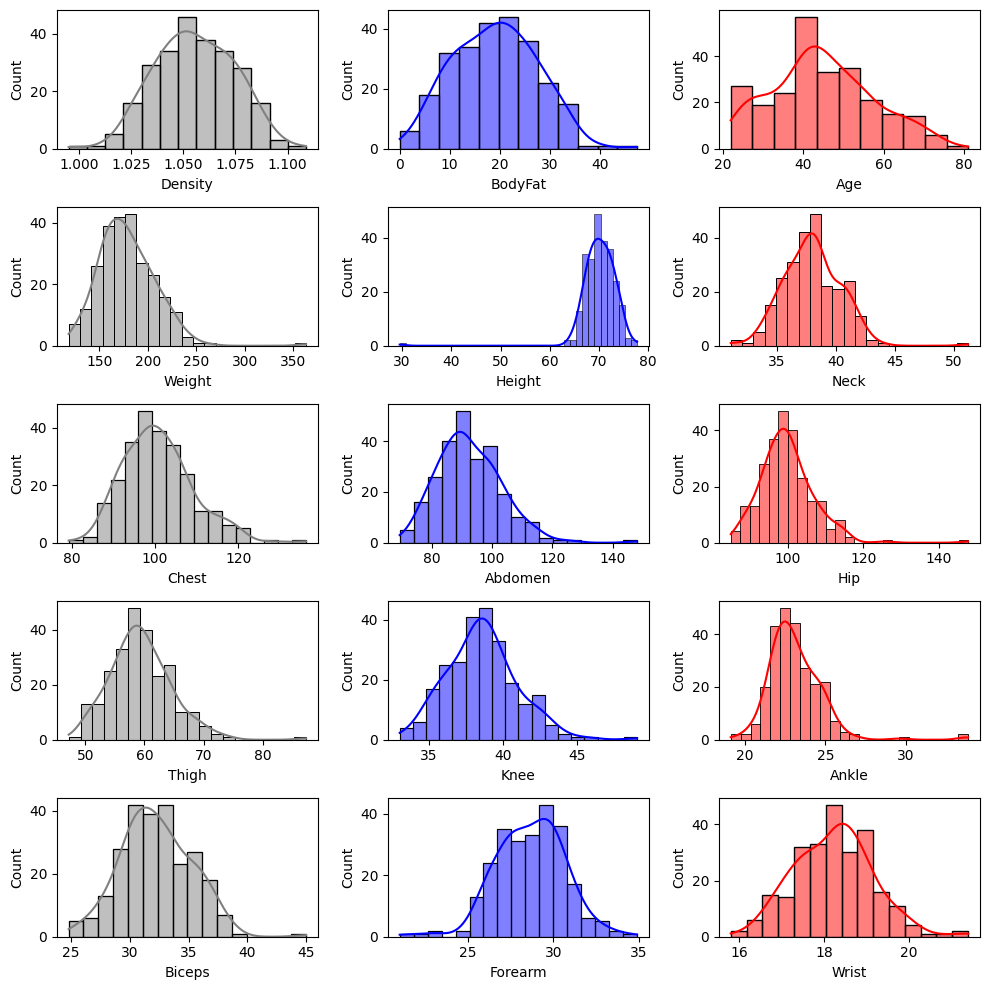

In [48]:
plot_histogramas(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

En alguno de estos gráficos se puede observar características calculadas sobre las variables.

Por ejemplo, las variables `Height`, `Hip` y `Ankle` tienen colas pesadas, lo cual se debe a su valores calculados de *Kurtosis* ($59.5$, $7.47$ y $11.9$ respectivamente).
También se observan asimetrías, tal como indican los valores de Skewness. Por ejemplo, `Height` tiene un valor de $-5.38$, lo cual explica su asimetría a izquierda.

### Paso 1.2 - Análisis de nulos

En esta sección se procede a realizar un análisis de datos faltantes.

Su tratamiento se realizará en secciones posteriores, una vez realizado el split del dataset en *train* y *test*.

Mediante el método `info` obtenemos otras características de las columnas, tales como la cantidad de datos no nulos (*Non-null count*) y el tipo de dato (*Dtype*).

Se observa lo siguiente:

- Ninguna columna tiene valores nulos.
- Todas las columnas son numéricas continuas (*float64*), a excepción de la columna `Age` (edad), que es numérica discreta (*int64*).

In [7]:
body_fat_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


Si bien el método `info` indica que no hay datos nulos, validamos esto de la siguiente manera:

In [ ]:
body_fat_dataset.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Si bien pandas se encarga de tratar los *Null*/*None* como *NaN* (más info [aquí](https://medium.com/@allenhuang1996/whats-the-difference-between-null-and-nan-in-python-a1af20d523ce)), se procede a hacer el análisis de la siguiente manera:

In [ ]:
body_fat_dataset.isna().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Como el dataset contiene información correspondiente a distintas mediciones, también consideraremos nulos a aquellos registros que tengan columnas con valores ceros.

A continuación, se observa el único registro con columnas con valores ceros. En este caso corresponde al registro número 181, y el valor en cero es la columna `BodyFat`.

In [100]:
for col in body_fat_dataset.columns:
    mascara = body_fat_dataset[col] == 0
    data_ceros = body_fat_dataset[mascara]
    cant_ceros = len(data_ceros)

    if cant_ceros > 0:
        print(data_ceros)

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


La conclusión de esta sección dedicada al análisis de nulos es que el dataset prácticamente no tiene valores faltantes, a excepción de un solo registro con valor de `BodyFat` en cero.

El tratamiento de este registro se realizará en secciones posteriores, luego de realizar el split en *train* y *test*.

### Paso 1.3 - Análisis de outliers

En esta sección se realizará un análisis de outliers para el dataset de `Body Fat prediction`.

En caso de encontrar outliers, se tratará a estos una vez realizado el split del dataset original en *train* y *test*.

In [101]:
def calcular_cantidad_outliers(dataset, col):
    data = dataset[col]
    Q1, Q2, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    mascara_min_iqr = data < min_iqr
    mascara_max_iqr = data > max_iqr

    cant_outliers_izq = len(dataset[mascara_min_iqr])
    cant_outliers_der = len(dataset[mascara_max_iqr])
    total_outliers = cant_outliers_izq + cant_outliers_der

    return total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr

Se procede a realizar un análisis de outliers de manera cuantitativa, utilizando el rango intercuartil.

El rango intercuartil se define como la diferencia del cuartil tres (75% de los datos) con el cuartil uno (25% de los datos), es decir $IQR = Q3 - Q1$.

Se consideran outliers a:

- Valores menores a $Q1 - 1.5 * IQR$ (los llamaremos outliers a izquierda).
- Valores mayores a $Q3 + 1.5 * IQR$ (los llamaremos outliers a derecha).

En la siguiente tabla se observan los resultados del análisis cuantitativo de outliers para el dataset de `Body Fat prediction`.

La variable con mayor cantidad de outliers es `Forearm`, la cual tiene $5$ outliers.

|	Columna	|Total de outliers|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
| --- |--- |--- |--- |--- |--- |--- |--- |--- |
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|	1.2	|	15.8	|	20.6	|

In [ ]:
print("|\tColumna\t|\tTotal de outliers\t|\tOutliers a izquierda\t|\tOutliers a derecha\t|\tQ1\t|\tQ3\t|\tIQR\t|\tQ1-1.5*IQR\t|\tQ3+1.5*IQR\t|")
for col in body_fat_dataset.columns:
    total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr = calcular_cantidad_outliers(body_fat_dataset, col)

    print(f"|\t{col}\t|\t{total_outliers}\t|\t{cant_outliers_izq}\t|\t{cant_outliers_der}\t|\t{np.round(Q1, 2)}\t|\t{np.round(Q3, 2)}\t|\t{np.round(IQR, 2)}\t|\t{np.round(min_iqr, 2)}\t|\t{np.round(max_iqr, 2)}\t|")


|	Columna	|Total de outliers|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|	1

A continuación se crea una función que permite graficar para cada variable un Boxplot.

Esto permite observar gráficamente a los outliers de cada variable.

In [122]:
def plot_boxplot(data, columns, figsize=(5,5), ncols=3, colores = ["gray", "lightblue", "green"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.boxplot(x=data[col], ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])

        axes[math.floor(i/ncols), i%ncols].set_xlabel(col)
        axes[math.floor(i/ncols), i%ncols].set_title(f"Boxplot para {col}")
    
    plt.tight_layout()
    plt.show()

    return

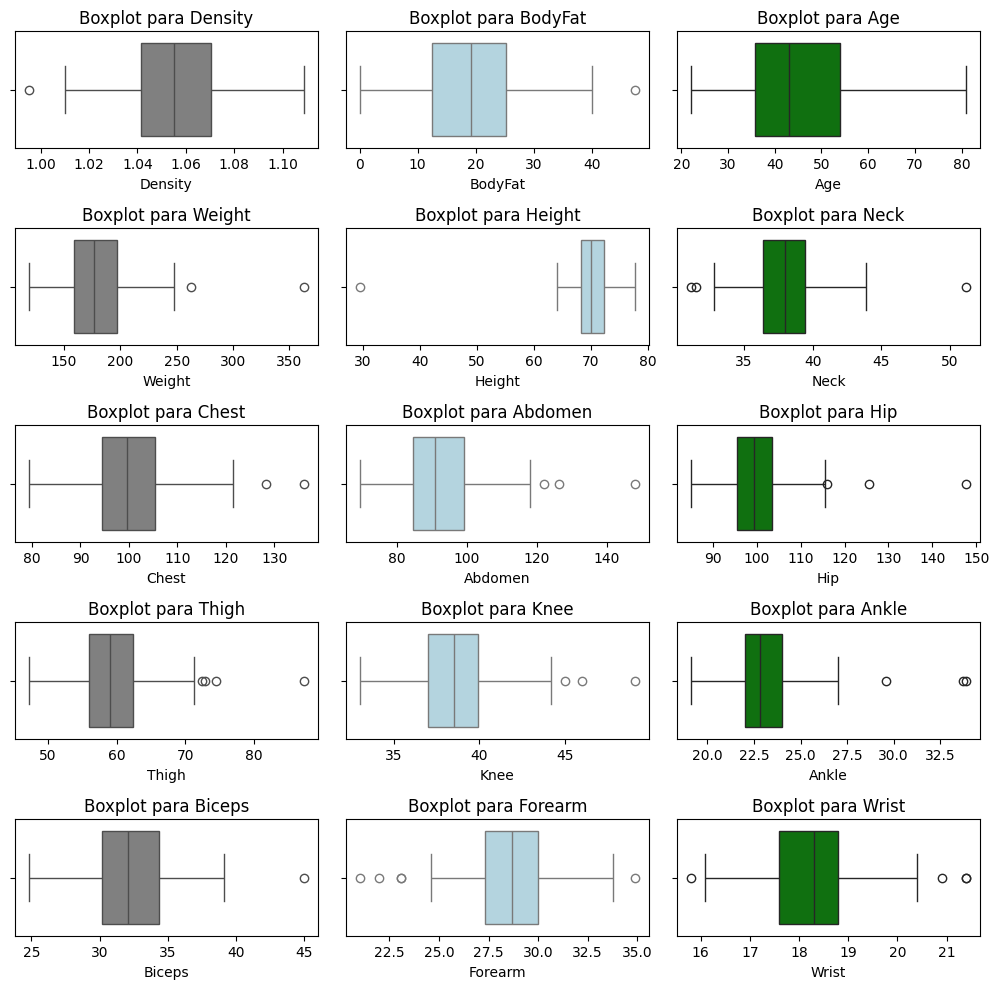

In [123]:
plot_boxplot(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

Como conclusión de esta sección podemos decir que, a excepción de `Age`, todas las variables presentan outliers en el dataset.

El tratamiento de estos se realizará en secciones posteriores, una vez se haya realizado el split en *Train* y *Test*.

### Paso 1.3 - Análisis de relación entre variable target y el resto de las variables